/home/x-uheede/.conda/envs/2024.02-py311/roms-tools/lib/python3.11/site-packages/dask/_task_spec.py:758: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  return self.func(*new_argspec, **kwargs)


<xarray.Dataset> Size: 1GB
Dimensions:   (time: 696, eta_rho: 258, xi_rho: 258)
Coordinates:
    abs_time  (time) datetime64[ns] 6kB dask.array<chunksize=(512,), meta=np.ndarray>
  * time      (time) timedelta64[ns] 6kB 8797 days 00:00:00 ... 8825 days 23:...
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    uwnd      (time, eta_rho, xi_rho) float32 185MB dask.array<chunksize=(1, 258, 258), meta=np.ndarray>
    vwnd      (time, eta_rho, xi_rho) float32 185MB dask.array<chunksize=(1, 258, 258), meta=np.ndarray>
    swrad     (time, eta_rho, xi_rho) float32 185MB dask.array<chunksize=(1, 258, 258), meta=np.ndarray>
    lwrad     (time, eta_rho, xi_rho) float32 185MB dask.array<chunksize=(1, 258, 258), meta=np.ndarray>
    Tair      (time, eta_rho, xi_rho) float32 185MB dask.array<chunksize=(1, 258, 258), meta=np.ndarray>
    rain      (time, eta_rho, xi_rho) float32 185MB dask.array<chunksize=(1, 258, 258), meta=np.ndarray>
    qair      (time, eta_rho, xi_rho) float32 

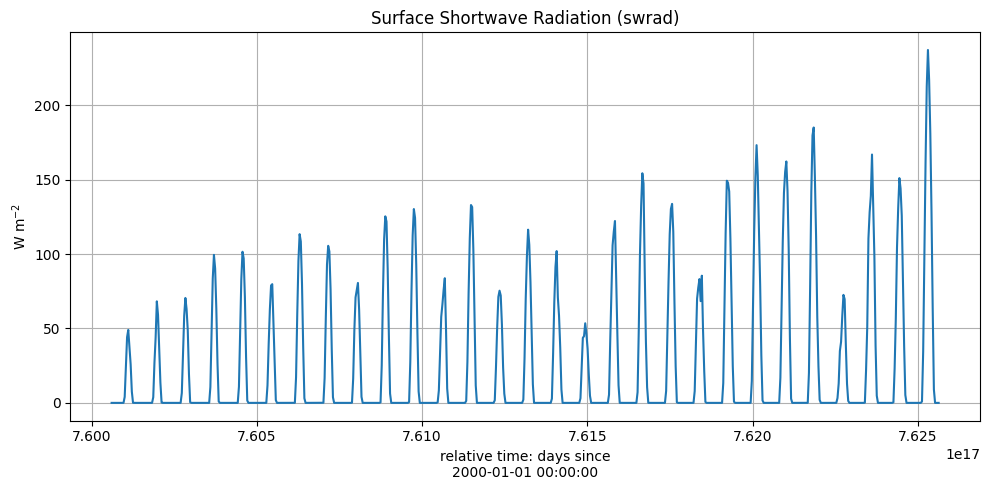


Summary statistics:
Minimum value: -3.630038918345235e-05
Maximum value: 237.0478973388672
Fraction of values near zero (<1 W/m²): 0.64
✔ swrad clearly varies between night (near zero) and daytime (positive values).


In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# 1. Open files
# --------------------------------------------------
path = "/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/RT_EMOD/*surface_forcing*202402*.nc"

ds = xr.open_mfdataset(
    path,
    combine="by_coords",
    parallel=True
)

print(ds)

# --------------------------------------------------
# 2. Extract swrad
# --------------------------------------------------
swrad = ds["swrad"]

print("\nVariable info:")
print(swrad)

# --------------------------------------------------
# 3. If spatial dimensions exist, take spatial mean
# --------------------------------------------------
spatial_dims = [dim for dim in swrad.dims if dim not in ["time"]]

if spatial_dims:
    swrad_ts = swrad.mean(dim=spatial_dims, skipna=True)
else:
    swrad_ts = swrad

# --------------------------------------------------
# 4. Plot time series
# --------------------------------------------------
plt.figure(figsize=(10,5))
swrad_ts.plot()
plt.title("Surface Shortwave Radiation (swrad)")
plt.ylabel("W m$^{-2}$")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5. Confirm day–night variability
# --------------------------------------------------

print("\nSummary statistics:")
print(f"Minimum value: {float(swrad_ts.min())}")
print(f"Maximum value: {float(swrad_ts.max())}")

# Check if nighttime values approach zero
night_fraction = float((swrad_ts < 1).sum() / swrad_ts.size)

print(f"Fraction of values near zero (<1 W/m²): {night_fraction:.2f}")

if swrad_ts.max() > 100 and swrad_ts.min() <= 1:
    print("✔ swrad clearly varies between night (near zero) and daytime (positive values).")
else:
    print("⚠ swrad does not show clear day–night contrast. Inspect time resolution and units.")
